In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as   plt 
import seaborn as sns

import sys

sys.path.append('./source')
from sklearn.model_selection import train_test_split


## Importation des fonctions


In [2]:
from  onlineMROTauc_eval import OnlineMROTAD
from offline import OfflineMROT
from utils import plot_auc_over_time, plot_auc_with_drift, split_data

from onlineMROTwassertein import OnlineMROTADWassertein

2026-02-04 20:30:08.875189: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-04 20:30:08.891097: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770233408.917554  346348 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770233408.925081  346348 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770233408.949198  346348 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770233408.949236  346348 computation_placer.cc:177] computation placer already registered. Please che

In [3]:
s1 = pd.read_csv("./datasets/cao2025/S1.csv")

In [4]:
data = s1.iloc[:,:-2]

drift_labels = s1.iloc[:,-1]
true_labels = s1.iloc[:,-2]

In [5]:
X_train, X_test, y_drift_train, y_drift_test, y_true_train, y_true_test = split_data(data, drift_labels, true_labels, n_train_samples=2000)

In [22]:
od = online = OnlineMROTAD(
    mrot_params={},
    window_size=400,
    n_history=5,            
    m_barycenter=3,
    theta_validation=0.80,
    tau_anomaly=0.75,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
    drift_threshold=0.5
)       

Anomaly scores for initial data computed. AUC Score: 0.9932116996951219


In [23]:
result = od.online_tumbling_window()

 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!


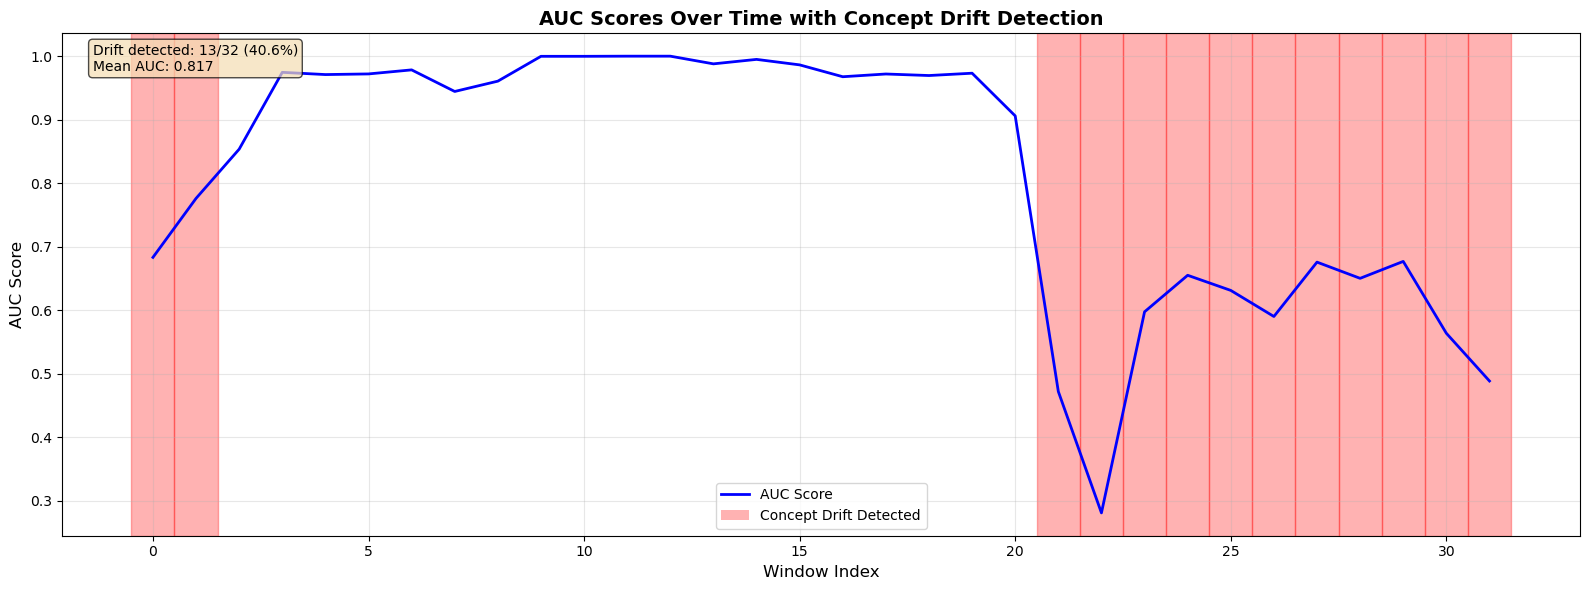

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [24]:
auc_lists = result[0]
drift_indicators = result[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

In [25]:
result2 = od.online_sliding_window()

 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model r

In [10]:
len(auc_lists)

64

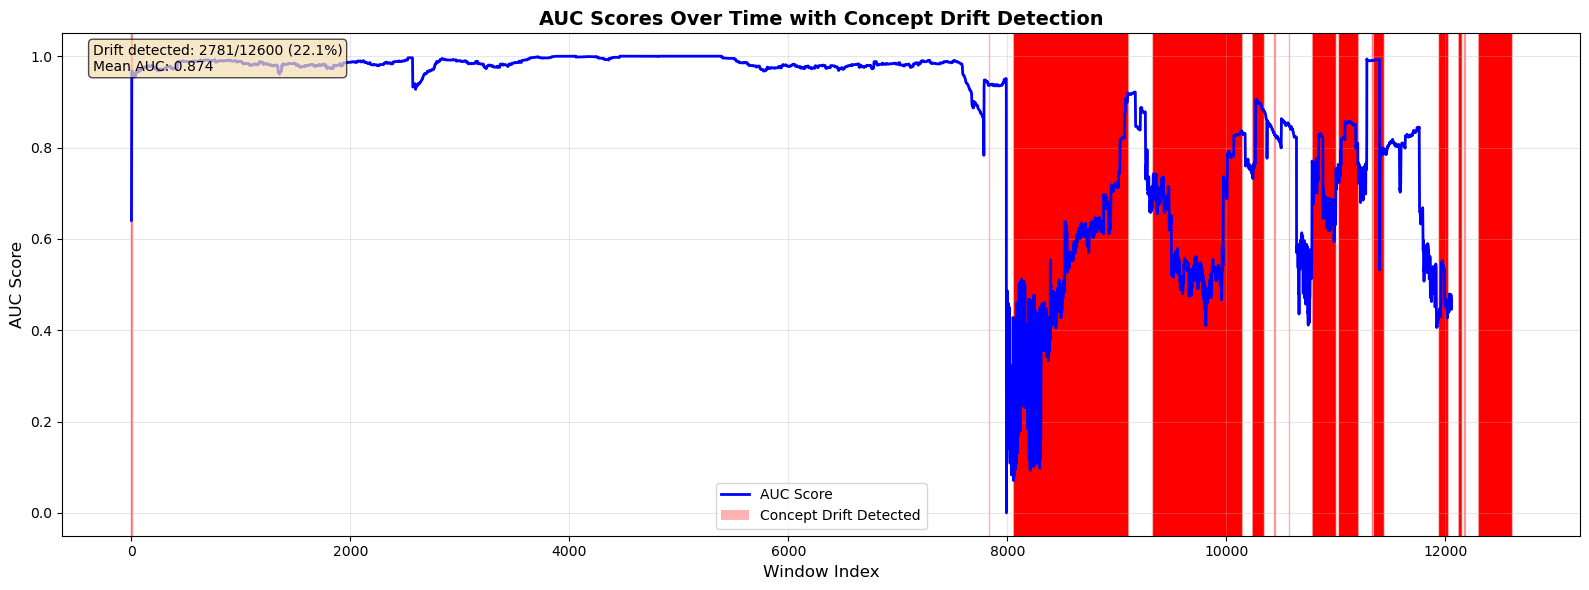

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [26]:
auc_lists = result2[0]
drift_indicators = result2[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

# 2 - Wassertein

In [39]:
ow = online = OnlineMROTADWassertein(
    mrot_params={},
    window_size=200,
    n_history=5,            
    m_barycenter=10,
    theta_validation=0.75,
    tau_anomaly=0.75,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
    drift_threshold=0.5
)       

Anomaly scores for initial data computed. AUC Score: 0.9932116996951219


In [40]:
score_list, drift_detected_list, wasserstein_score = ow.online_wasserstein_structured()

 PERFORMANCE DRIFT! AUC below threshold: 0.6497
Window 1: AUC=0.6497, Wasserstein=0.0000
Window 2: AUC=0.8317, Wasserstein=0.0000
 PERFORMANCE DRIFT! AUC below threshold: 0.6919
Window 3: AUC=0.6919, Wasserstein=0.0000
Window: Wasserstein=0.0000 (AUC not computable)
Window 4: AUC=0.8299, Wasserstein=0.0000
 WASSERSTEIN DRIFT! Distance: 0.5582 > Threshold: 0.5000
 PERFORMANCE DRIFT! AUC below threshold: 0.7284
Window 5: AUC=0.7284, Wasserstein=0.5582
 Model retrained successfully!
 Drift detected: Model updated, historical windows NOT updated.
 WASSERSTEIN DRIFT! Distance: 0.6512 > Threshold: 0.5000
Window 6: AUC=0.9773, Wasserstein=0.6512
 Model retrained successfully!
 Drift detected: Model updated, historical windows NOT updated.
Window: Wasserstein=0.4814 (AUC not computable)
 Historical windows updated. New adaptive threshold: 0.2
 WASSERSTEIN DRIFT! Distance: 0.3000 > Threshold: 0.2000
Window: Wasserstein=0.3000 (AUC not computable)
 Model retrained successfully!
 Drift detected: 

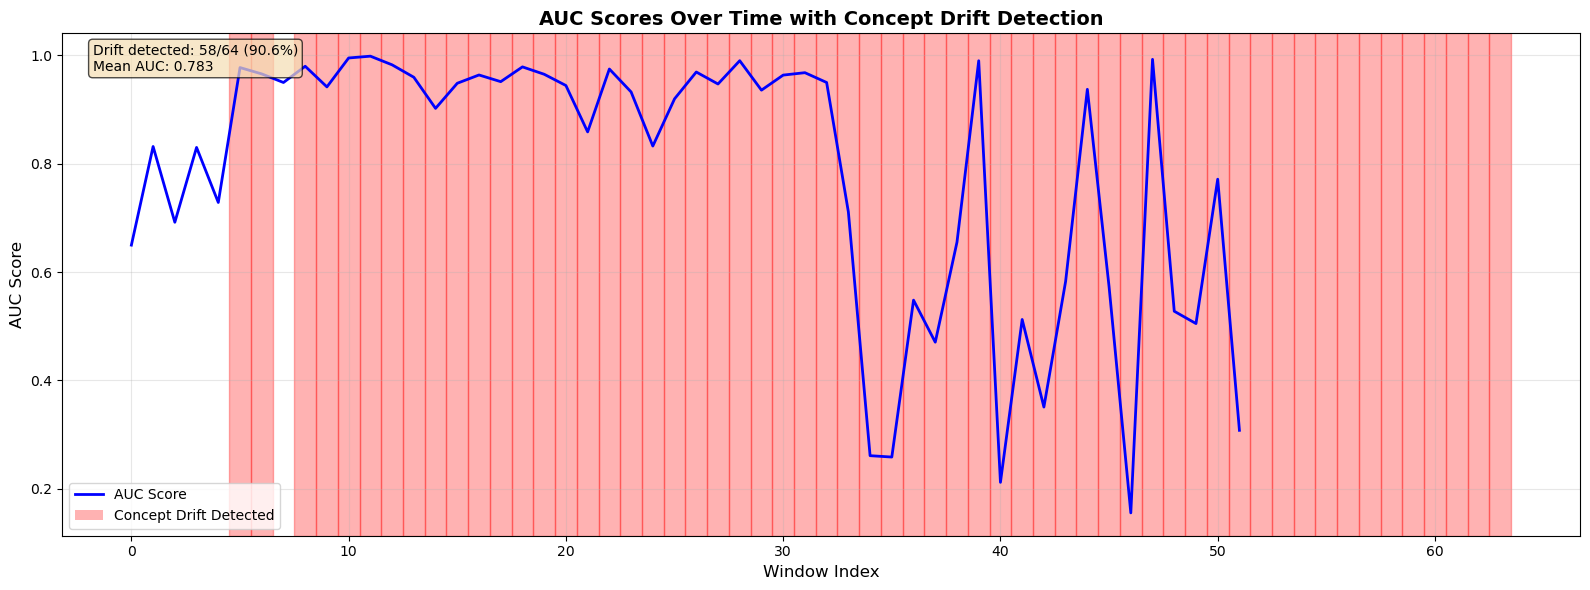

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [41]:
plot_auc_with_drift(score_list, drift_detected_list)

Text(0.5, 0, 'Window Index')

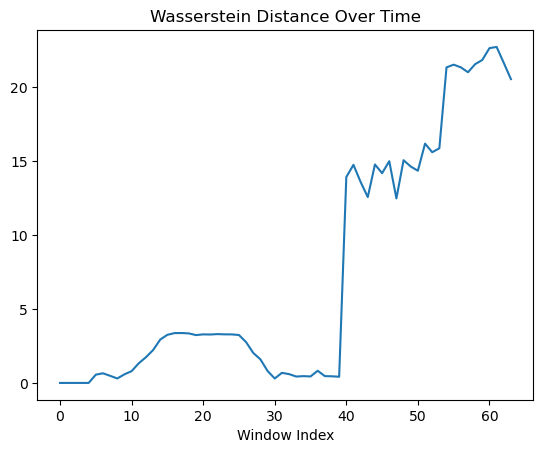

In [42]:
plt.plot(wasserstein_score)
plt.title("Wasserstein Distance Over Time")
plt.xlabel("Window Index")

In [43]:
test =  ow.online_domain_adaptation()

Window 1: AUC=0.9365
Window 2: AUC=0.7990
Window 3: AUC=0.8990
Window 4: AUC=0.7919
Window 5: AUC=0.8748
Window 6: AUC=0.9116
Window 7: AUC=0.9145
Window 8: AUC=1.0000
Window 9: AUC=0.9036
Window 10: AUC=0.9619
Window 11: AUC=0.9447
 PERFORMANCE DRIFT! AUC below threshold: 0.6447
Window 12: AUC=0.6447
 Drift detected: Model updated.
le cout de transport est   0.350370621573535
 Model retrained successfully!
Window 13: AUC=0.9823
Window 14: AUC=0.9662
Window 15: AUC=0.9598
Window 16: AUC=0.9630
Window 17: AUC=0.9856
Window 18: AUC=0.9846
Window 19: AUC=0.9937
Window 20: AUC=0.9809
Window 21: AUC=0.9492
Window 22: AUC=0.8851
Window 23: AUC=0.8985
Window 24: AUC=0.7690
 PERFORMANCE DRIFT! AUC below threshold: 0.5406
Window 25: AUC=0.5406
 Drift detected: Model updated.
le cout de transport est   1.186816786404107
 Model retrained successfully!
Window 26: AUC=0.9196
Window 27: AUC=0.9420
Window 28: AUC=0.9394
Window 29: AUC=0.9523
Window 30: AUC=0.9343
Window 31: AUC=0.9457
Window 32: AUC=

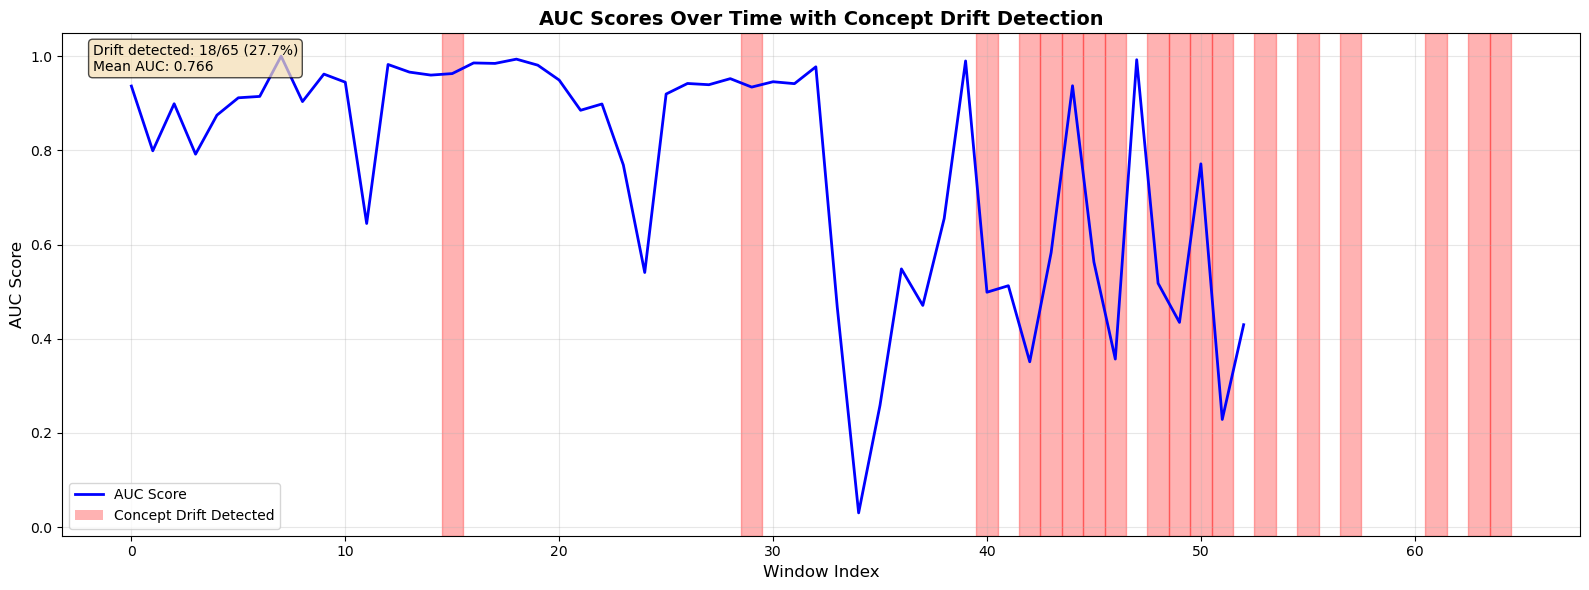

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [44]:
auc_lists = test[0]
drift_indicators = test[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

In [18]:
len(drift_indicators)

130